# F1 Fastest Race Lap Animations

In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# customize matplotlib theme and fonts
# import mplcyberpunk
import matplotlib.font_manager as fm
font_path = 'Path/to/project/Formula1-Bold_web.ttf'
fm.fontManager.addfont(font_path)
f1_font_name = fm.FontProperties(fname=font_path).get_name()

%matplotlib widget

In [2]:
fastf1.Cache.clear_cache('Path/to/project')
fastf1.Cache.enable_cache('Path/to/project')

session = session = fastf1.get_session(2025, 'Spain', 'R')
session.load()

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

In [3]:
# Get Track Data to Plot

lap = session.laps.pick_fastest()
track = lap.get_pos_data()

x = track['X']
y = track['Y']

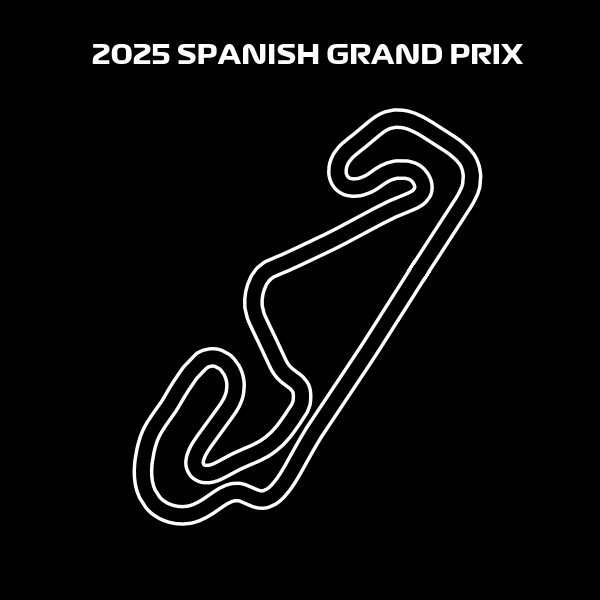

In [5]:
# Plot Track

plt.figure(figsize=(6, 6))
plt.plot(x, y, linewidth=15, color='white')
plt.plot(x, y, linewidth=10, color='black')


# Customize Plot
plt.style.use("dark_background")
plt.rcParams['font.family'] = f1_font_name
plt.rcParams['font.size'] = 16

plt.title('2025 SPANISH GRAND PRIX')
plt.axis('equal')
plt.ylim(-8000, 5500)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid(False)
plt.axis('off')

plt.show()

## Oscar Piastri Data

In [6]:
# Get Piastri Fastest Lap Data

pia_laps = session.laps.pick_drivers('PIA')
fastest_lap = pia_laps.pick_fastest()
telemetry = fastest_lap.get_telemetry()

# telemetry

In [7]:
pia_x = telemetry['X']
pia_y = telemetry['Y']

In [8]:
telemetry['Time'] = telemetry['Time'].dt.total_seconds()

In [9]:
x_pia = np.array(telemetry['X'])
y_pia = np.array(telemetry['Y'])
t_pia = np.array(telemetry['Time'])

telemetry["Time"].max()

75.743

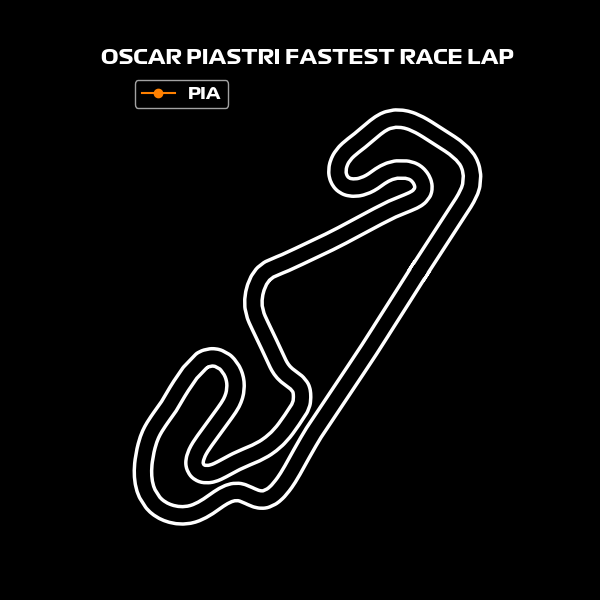

In [21]:
# Rough Animated Plot

fig, ax = plt.subplots(figsize=(6, 6))

# Plot track
ax.plot(x, y, color='white', linewidth=15)
ax.plot(x, y, color='black', linewidth=10)

# Car

animated_car, = ax.plot([], [], color='#FF8000', marker='o', markersize=6, label='PIA') # Change colour to desired team colour

ax.set_aspect('equal')
interval = (t_pia.max()/len(x_pia)) * 1000   #interval and frames change according to data points

def update(frame):
    animated_car.set_data([x_pia[frame]], [y_pia[frame]])
    return animated_car,

ani = FuncAnimation(
    fig=fig,
    func=update,
    frames=len(x_pia),
    interval=interval, #milliseconds
    blit=True
)

# Customize Plot
plt.style.use("dark_background")
plt.rcParams['font.family'] = f1_font_name
plt.rcParams['font.size'] = 12

plt.grid(False)
plt.axis('off')
plt.legend(loc='upper left')
plt.title("OSCAR PIASTRI FASTEST RACE LAP")
plt.ylim(-8000, 5500)

plt.show()
ani.save('Piastri.gif')
ani.save('Piastri.mp4')

## Kimi Antonelli Data

In [16]:
# Get Second Driver Data

# Get Stroll Fastest Lap Data

antonelli_laps = session.laps.pick_drivers('ANT')
fastest_lap_antonelli = antonelli_laps.pick_fastest()
antonelli_telemetry = fastest_lap_antonelli.get_telemetry()

antonelli_telemetry['Time'] = antonelli_telemetry['Time'].dt.total_seconds()

# antonelli_telemetry

In [17]:
x_ant = np.array(antonelli_telemetry['X'])
y_ant = np.array(antonelli_telemetry['Y'])
t_ant = np.array(antonelli_telemetry['Time'])

antonelli_telemetry["Time"].max()

78.255

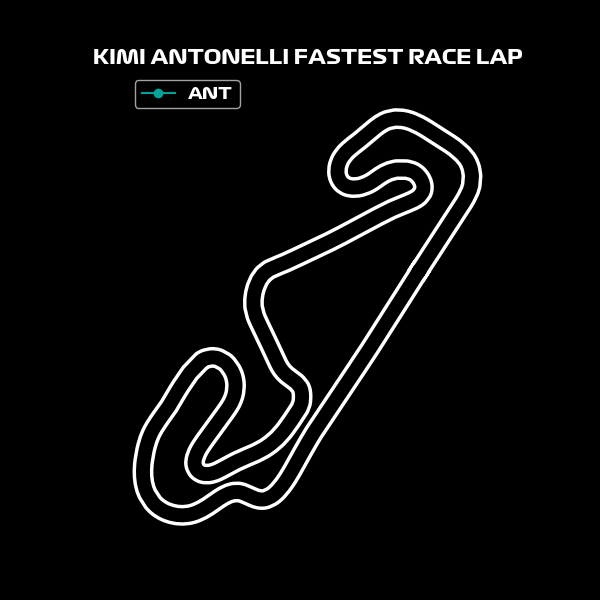

In [20]:
# Rough Animated Plot

fig, ax = plt.subplots(figsize=(6, 6))

# Plot track
ax.plot(x, y, color='white', linewidth=15)
ax.plot(x, y, color='black', linewidth=10)

# Car

animated_car, = ax.plot([], [], color='#00A19B', marker='o', markersize=6, label='ANT')

ax.set_aspect('equal')
interval = (t_ant.max()/len(x_ant)) * 1000   #interval and frames change according to data points

def update(frame):
    animated_car.set_data([x_ant[frame]], [y_ant[frame]])
    return animated_car,

ani = FuncAnimation(
    fig=fig,
    func=update,
    frames=len(x_ant),
    interval=interval, #milliseconds
    blit=True
)

# Customize Plot
plt.style.use("dark_background")
plt.rcParams['font.family'] = f1_font_name
plt.rcParams['font.size'] = 12

plt.grid(False)
plt.axis('off')
plt.legend(loc='upper left')
plt.title('KIMI ANTONELLI FASTEST RACE LAP')
plt.ylim(-8000, 5500)

plt.show()
ani.save('Antonelli.gif')
ani.save('Antonelli.mp4')